# EKFAC Influence Score Comparison

Compare EKFAC-preconditioned influence scores between bergson and kronfluence.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr

In [2]:
# Works whether notebook runs from repo root or from ekfac_scores/
RESULTS = Path("results")
if not RESULTS.is_dir():
    RESULTS = Path("ekfac_scores/results")

berg_flat = torch.load(RESULTS / "bergson_scores.pt").numpy()
kron_flat = torch.load(RESULTS / "kronfluence_scores.pt").numpy()

print(
    f"bergson:      shape={berg_flat.shape}, range=[{berg_flat.min():.6e}, {berg_flat.max():.6e}]"
)
print(
    f"kronfluence:  shape={kron_flat.shape}, range=[{kron_flat.min():.6e}, {kron_flat.max():.6e}]"
)
print(f"NaN? bergson={np.isnan(berg_flat).any()}, kron={np.isnan(kron_flat).any()}")

bergson:      shape=(10000,), range=[-1.766061e-01, 2.713351e-02]
kronfluence:  shape=(10000,), range=[-6.483122e+03, 2.067840e+04]
NaN? bergson=False, kron=False


In [3]:
import json

scores_path = Path("/root/bergson/scripts/runs_test/ekfac_scores/scores")
new_path = scores_path / "scores.bin"
with open(scores_path / "info.json") as f:
    info = json.load(f)

dt = np.dtype(info["dtype"])
memmap_scores = np.memmap(new_path, dtype=dt, mode="r")
scores = memmap_scores["score_0"]  # shape (10000,)

FileNotFoundError: [Errno 2] No such file or directory: '/root/bergson/scripts/runs_test/ekfac_scores/scores/info.json'

In [34]:
scores

memmap([0.19841124, 0.05955154, 0.04279691, ..., 0.05136644, 0.18130913,
        0.08096746], shape=(10000,), dtype=float32)

In [35]:
berg_flat = scores


Spearman rho = 0.998581, p-value = 0.00e+00
Linear fit: slope = 14681.028624, intercept = 3.217518e+00


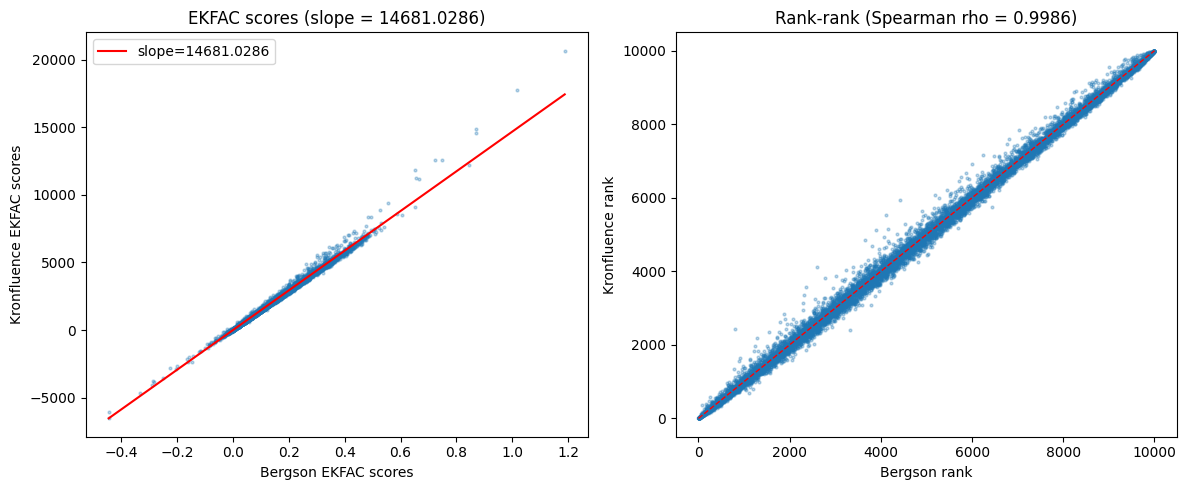

In [36]:
# ── Spearman correlation ─────────────────────────────────────────────────────
rho, pval = spearmanr(berg_flat, kron_flat)
print(f"\nSpearman rho = {rho:.6f}, p-value = {pval:.2e}")

# ── Linear fit ───────────────────────────────────────────────────────────────
slope, intercept = np.polyfit(berg_flat, kron_flat, 1)
print(f"Linear fit: slope = {slope:.6f}, intercept = {intercept:.6e}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter + fitted line
axes[0].scatter(berg_flat, kron_flat, alpha=0.3, s=4)
x_line = np.array([berg_flat.min(), berg_flat.max()])
axes[0].plot(
    x_line, slope * x_line + intercept, "r-", linewidth=1.5, label=f"slope={slope:.4f}"
)
axes[0].set_xlabel("Bergson EKFAC scores")
axes[0].set_ylabel("Kronfluence EKFAC scores")
axes[0].set_title(f"EKFAC scores (slope = {slope:.4f})")
axes[0].legend()

# Rank-rank plot
berg_ranks = np.argsort(np.argsort(berg_flat))
kron_ranks = np.argsort(np.argsort(kron_flat))
axes[1].scatter(berg_ranks, kron_ranks, alpha=0.3, s=4)
axes[1].plot([0, len(berg_flat)], [0, len(berg_flat)], "r--", linewidth=1)
axes[1].set_xlabel("Bergson rank")
axes[1].set_ylabel("Kronfluence rank")
axes[1].set_title(f"Rank-rank (Spearman rho = {rho:.4f})")

plt.tight_layout()
plt.show()